In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5) (1).zip


In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Files extracted to /content/data")

Files extracted to /content/data


In [ ]:
import os

for root, dirs, files in os.walk('/content/data'):
    for file in files:
        print(os.path.join(root, file))

/content/data/Amazon-Product-Reviews - Amazon Product Review (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/data/Amazon-Product-Reviews - Amazon Product Review (1).csv')
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1


In [ ]:
df = df[['review_body', 'star_rating']]  # adjust if column names differ
df.dropna(inplace=True)

# Convert ratings to sentiment
def get_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Sentiment'] = df['star_rating'].apply(get_sentiment)
df = df.rename(columns={'review_body': 'Text', 'star_rating': 'Score'})
df.head()

,Text,Score,Sentiment
0,Great love it,5,positive
1,Lots of ads<br />Slow processing speed<br />Oc...,3,neutral
2,Excellent unit. The versatility of this table...,5,positive
3,I bought this on Amazon Prime so I ended up bu...,4,positive
4,All Amazon products continue to meet my expect...,5,positive


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = nltk.word_tokenize(text)

    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(tokens)

df['Clean_Text'] = df['Text'].apply(preprocess)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Text,Score,Sentiment,Clean_Text
0,Great love it,5,positive,great love
1,Lots of ads<br />Slow processing speed<br />Oc...,3,neutral,lot ad br slow processing speed br occasionall...
2,Excellent unit. The versatility of this table...,5,positive,excellent unit versatility tablet besides comp...
3,I bought this on Amazon Prime so I ended up bu...,4,positive,bought amazon prime ended buying gb one camera...
4,All Amazon products continue to meet my expect...,5,positive,amazon product continue meet expectation


In [ ]:
from sklearn.model_selection import train_test_split

X = df['Clean_Text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=300)

In [ ]:
import pickle

pickle.dump(model, open("sentiment_model.pkl", "wb"))

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Logistic Regression:\n", classification_report(y_test, lr_pred))
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nNaive Bayes:\n", classification_report(y_test, nb_pred))
print("Accuracy:", accuracy_score(y_test, nb_pred))

# Generate predictions for the main Logistic Regression model (named 'model')
model_pred = model.predict(X_test_tfidf)
print("\nMain Logistic Regression Model:\n", classification_report(y_test, model_pred))
print("Accuracy:", accuracy_score(y_test, model_pred))

Logistic Regression:
               precision    recall  f1-score   support

    negative       0.71      0.55      0.62       546
     neutral       0.38      0.12      0.19       410
    positive       0.91      0.98      0.95      5213

    accuracy                           0.89      6169
   macro avg       0.67      0.55      0.58      6169
weighted avg       0.86      0.89      0.87      6169

Accuracy: 0.8863673204733344

Naive Bayes:
               precision    recall  f1-score   support

    negative       0.71      0.44      0.55       546
     neutral       0.38      0.04      0.07       410
    positive       0.89      0.99      0.94      5213

    accuracy                           0.88      6169
   macro avg       0.66      0.49      0.52      6169
weighted avg       0.84      0.88      0.85      6169

Accuracy: 0.8772896741773383

Main Logistic Regression Model:
               precision    recall  f1-score   support

    negative       0.46      0.64      0.53       546


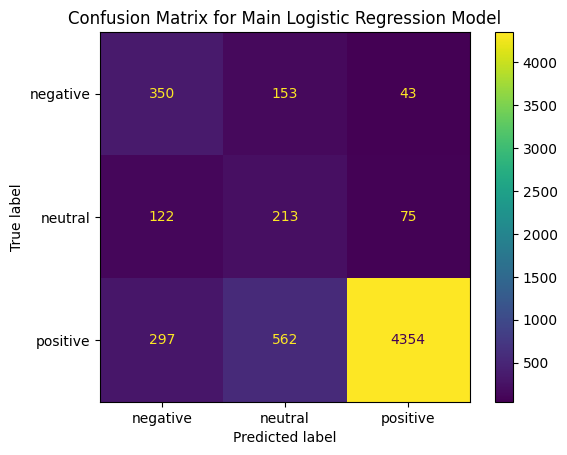

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Use 'model_pred' which contains predictions from the main Logistic Regression model
ConfusionMatrixDisplay.from_predictions(y_test, model_pred)
plt.title('Confusion Matrix for Main Logistic Regression Model')
plt.show()

In [ ]:
!pip install transformers

In [ ]:
from transformers import pipeline
import numpy as np

# Balanced sampling
df = df.groupby('Sentiment').apply(lambda x: x.sample(1000)).reset_index(drop=True)

# Lightweight model
emotion_model = pipeline(
    "text-classification",
    model="bhadresh-savani/distilbert-base-uncased-emotion",
    device=-1
)

def detect_emotions_batch(texts, batch_size=64):
    texts = texts.fillna("").str[:256]

    emotions = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        results = emotion_model(batch)
        emotions.extend([res['label'] for res in results])

    return emotions

df['Emotion'] = detect_emotions_batch(df['Clean_Text'])

/tmp/ipykernel_2925/308266415.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Sentiment').apply(lambda x: x.sample(1000)).reset_index(drop=True)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

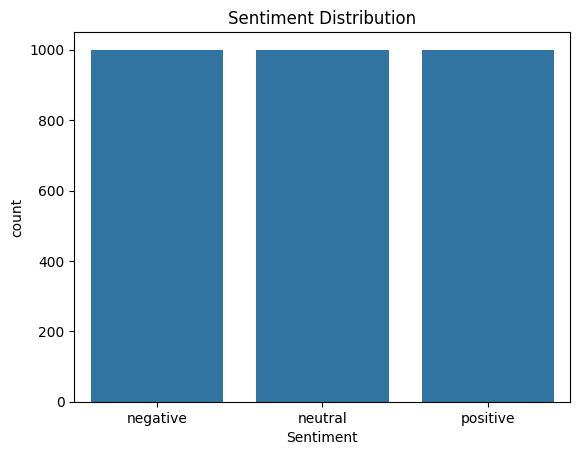

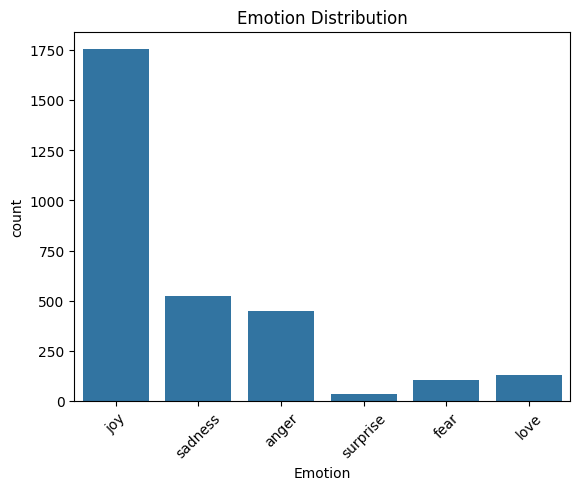

In [ ]:
import seaborn as sns

sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

sns.countplot(x='Emotion', data=df)
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
def refine_emotion(emotions, sentiment):
    top_emotion = emotions[0]['label']
    if sentiment == "negative" and top_emotion == "joy":
        for emo in emotions:
            if emo['label'] in ["anger", "sadness", "fear"]:
                return emo['label']
    return top_emotion

def fix_negation(text, sentiment):
    neg_words = ["not", "no", "never", "n't"]
    for word in neg_words:
        if word in text:
            if sentiment == "positive":
                return "negative"
    return sentiment

def predict_review(text):
    cleaned = preprocess(text)
    vector = tfidf.transform([cleaned])

    # Sentiment prediction
    sentiment = model.predict(vector)[0]
    sentiment = fix_negation(cleaned, sentiment)

    # Emotion prediction
    emotion_results = emotion_model(cleaned[:256], top_k=3)
    emotion = refine_emotion(emotion_results, sentiment)

    print("Review:", text)
    print("Sentiment:", sentiment)
    print("Emotion:", emotion)

predict_review("This product is amazing and I love it!")

Review: This product is amazing and I love it!
Sentiment: positive
Emotion: joy


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 17.5 MB/s eta 0:00:00


In [ ]:
import gensim
from gensim.models import Word2Vec
import numpy as np

In [ ]:
tokenized_text = df['Clean_Text'].apply(lambda x: x.split())

In [ ]:
w2v_model = Word2Vec(
    sentences=tokenized_text,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
def get_avg_word2vec(tokens, model, vector_size):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)

In [ ]:
X_w2v = np.array([
    get_avg_word2vec(tokens, w2v_model, 100)
    for tokens in tokenized_text
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, df['Sentiment'], test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300, class_weight='balanced')
model.fit(X_train_tfidf, y_train)
w2v_model_lr = LogisticRegression(max_iter=200)
w2v_model_lr.fit(X_train_w2v, y_train_w2v)

LogisticRegression(max_iter=200)

In [ ]:
import pickle

pickle.dump(model, open("sentiment_model.pkl", "wb"))

In [ ]:
print(X_test_w2v.shape)
print(y_test_w2v.shape)
# Generate predictions first
w2v_pred = w2v_model_lr.predict(X_test_w2v)

# Then print results
from sklearn.metrics import classification_report, accuracy_score

print("Word2Vec Model:\n")
print(classification_report(y_test_w2v, w2v_pred))
print("Accuracy:", accuracy_score(y_test_w2v, w2v_pred))

(600, 100)
(600,)
Word2Vec Model:

              precision    recall  f1-score   support

    negative       0.55      0.44      0.49       217
     neutral       0.42      0.49      0.45       197
    positive       0.54      0.58      0.56       186

    accuracy                           0.50       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.50      0.50      0.50       600

Accuracy: 0.49833333333333335


In [ ]:
from sklearn.model_selection import train_test_split

# Re-create the original y_test for TF-IDF models as it was overwritten.
# X and y still hold the full dataset's clean text and sentiment before sampling.
_, _, _, y_test_tfidf_original = train_test_split(X, y, test_size=0.2, random_state=42)

print("TF-IDF Accuracy:", accuracy_score(y_test_tfidf_original, model_pred))
print("Word2Vec Accuracy:", accuracy_score(y_test_w2v, w2v_pred))

TF-IDF Accuracy: 0.7970497649538013
Word2Vec Accuracy: 0.49833333333333335


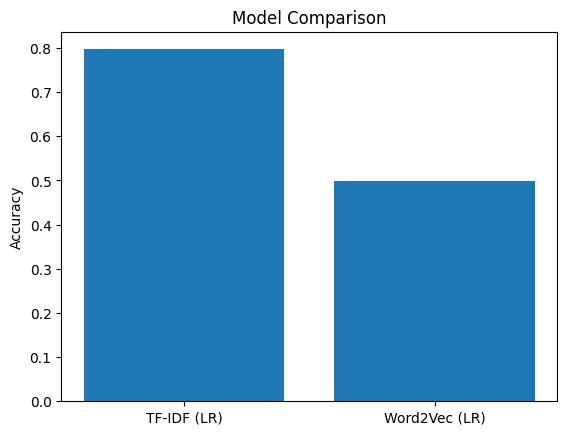

In [ ]:
import matplotlib.pyplot as plt

# Re-create the original y_test for TF-IDF models as it was overwritten.
# X and y still hold the full dataset's clean text and sentiment before sampling.
_, _, _, y_test_tfidf_original = train_test_split(X, y, test_size=0.2, random_state=42)

models = ['TF-IDF (LR)', 'Word2Vec (LR)']
accuracies = [
    accuracy_score(y_test_tfidf_original, model_pred),
    accuracy_score(y_test_w2v, w2v_pred)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.3 MB/s eta 0:00:00


In [ ]:
import pickle

# Save TF-IDF
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

# Save main Logistic Regression model (formerly SVM in older versions of the notebook)
pickle.dump(model, open("sentiment_model.pkl", "wb"))

In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from transformers import pipeline

# Download NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Load models
tfidf = pickle.load(open("tfidf.pkl", "rb"))
model = pickle.load(open("sentiment_model.pkl", "rb"))

# ✅ Improved Emotion Model
emotion_model = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    device=-1

)

# Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

# ✅ Emotion refinement logic
def refine_emotion(emotions, sentiment):
    top_emotion = emotions[0]['label']

    # Fix incorrect "joy" for negative sentiment
    if sentiment == "negative" and top_emotion == "joy":
        for emo in emotions:
            if emo['label'] in ["anger", "sadness", "fear"]:
                return emo['label']

    return top_emotion

def fix_negation(text, sentiment):
    neg_words = ["not", "no", "never", "n't"]

    for word in neg_words:
        if word in text:
            if sentiment == "positive":
                return "negative"

    return sentiment
# Page config
st.set_page_config(page_title="Sentiment Analyzer", layout="wide")

# Title
st.markdown("<h1 style='text-align: center; color: #4CAF50;'>🛍️ Product Review Sentiment & Emotion Analyzer</h1>", unsafe_allow_html=True)
st.markdown("### Analyze customer reviews with AI")

# Input
user_input = st.text_area("✍️ Enter your review:", height=150)

if st.button("🔍 Analyze Review"):

    if user_input.strip() == "":
        st.warning("Please enter a review.")
    else:
        cleaned = preprocess(user_input)
        vector = tfidf.transform([cleaned])

        # Sentiment prediction
        sentiment = model.predict(vector)[0]
        sentiment = fix_negation(cleaned, sentiment)

        probs = model.predict_proba(vector)
        confidence = round(max(probs[0]), 2)

        # Emotion prediction (top 3)
        emotion_results = emotion_model(cleaned[:256], top_k=3)
        emotion = refine_emotion(emotion_results, sentiment)
        emotion_score = round(emotion_results[0]['score'], 2)

        # Layout
        col1, col2 = st.columns(2)

        # Sentiment display
        with col1:
            st.markdown("### 📊 Sentiment")
            if sentiment == "positive":
                st.success(f"😊 {sentiment.upper()}")
            elif sentiment == "negative":
                st.error(f"😡 {sentiment.upper()}")
            else:
                st.warning(f"😐 {sentiment.upper()}")

        # Emotion display
        with col2:
            st.markdown("### 🎭 Emotion")
            st.info(f"{emotion} (Confidence: {emotion_score})")

        # Divider
        st.markdown("---")

        # Emotion confidence chart
        st.markdown("### 📈 Top Emotion Scores")
        st.write(f"Confidence: {confidence}")
        labels = [e['label'] for e in emotion_results]
        scores = [e['score'] for e in emotion_results]

        fig, ax = plt.subplots()
        ax.bar(labels, scores)
        ax.set_ylim(0, 1)
        st.pyplot(fig)

# Sidebar
st.sidebar.title("📌 About")
st.sidebar.info("""
This project uses:
- TF-IDF + SVM for Sentiment Analysis
- Transformer model for Emotion Detection
- NLP preprocessing pipeline

Built for NLP Mini Project 🚀
""")

Writing app.py


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3BKy33UFJKIAQ66HzvIVmHQGizc_2XLcoTB59e11guKqvJm1T")  # ✅ ONLY TOKEN

!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://unaccommodated-laci-characterless.ngrok-free.dev" -> "http://localhost:8501"


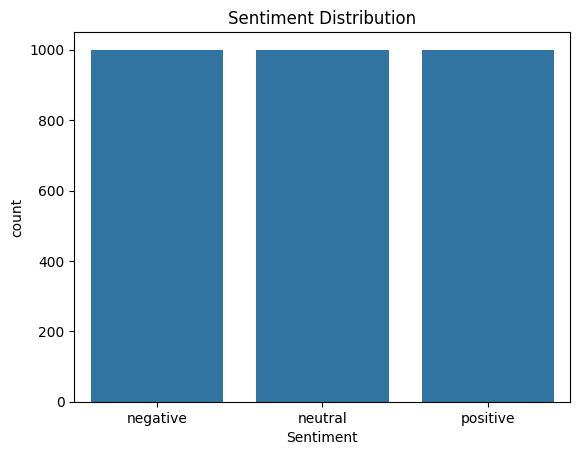

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

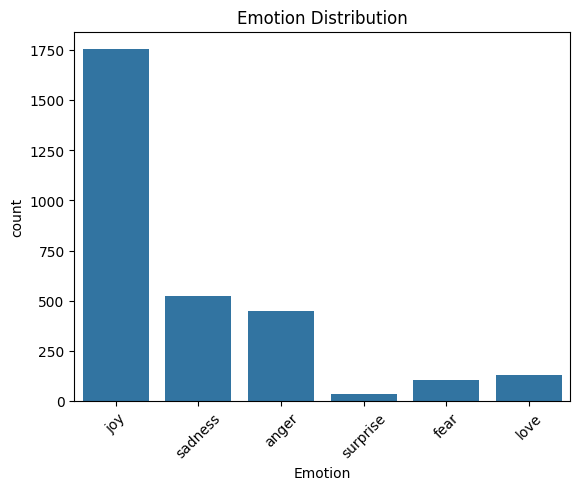

In [ ]:
sns.countplot(x='Emotion', data=df)
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

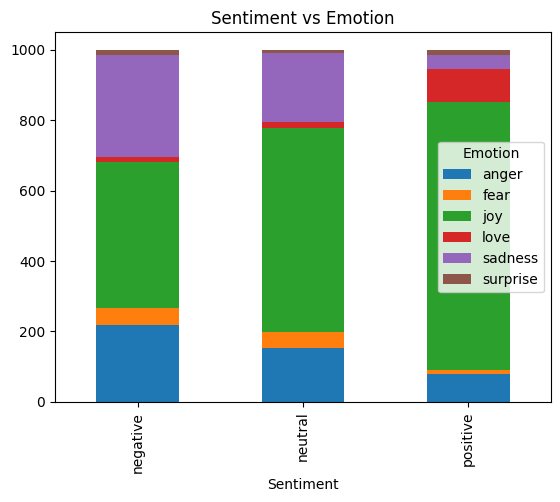

In [ ]:
cross_tab = pd.crosstab(df['Sentiment'], df['Emotion'])

cross_tab.plot(kind='bar', stacked=True)
plt.title("Sentiment vs Emotion")
plt.show()

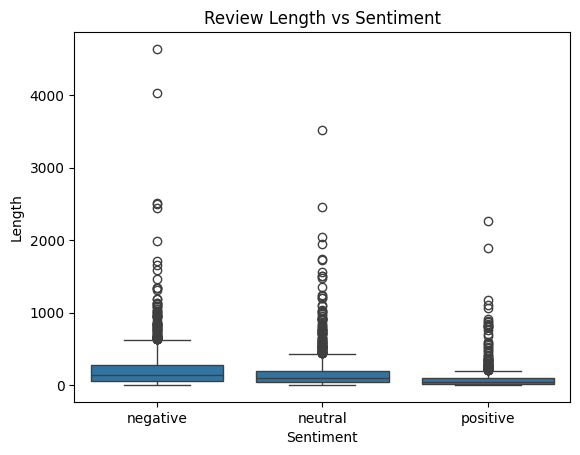

In [ ]:
df['Length'] = df['Clean_Text'].apply(len)

sns.boxplot(x='Sentiment', y='Length', data=df)
plt.title("Review Length vs Sentiment")
plt.show()

In [ ]:
!pip install wordcloud

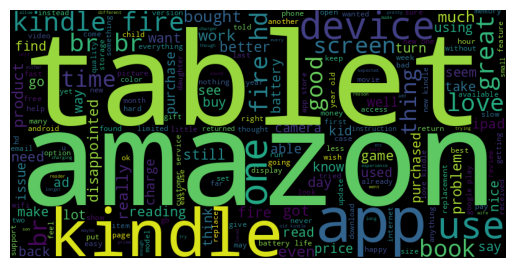

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['Clean_Text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()